## Bigram Language Models

In [1]:
from pathlib import Path
import requests

DATA_PATH = Path("data")
DATA_PATH.mkdir(exist_ok=True)

file_path = DATA_PATH / "names.txt"

if not file_path.exists():
    url = "https://raw.githubusercontent.com/karpathy/makemore/master/names.txt"
    file_path.write_text(requests.get(url).text)

words = file_path.read_text().splitlines()

print(f"Loaded {len(words)} names")

Loaded 32033 names


In [2]:
# Load Dataset
import torch
import matplotlib.pyplot as plt

with open("/Users/mac/Desktop/Machine Learning/DL/models/data/names.txt", "r") as f:
    words=f.read().splitlines()
    
print(f"Number of names:{len(words)}")
print(words[:10])

Number of names:32033
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']


In [3]:
## Build Vocabulary
chars=sorted(list(set("".join(words))))

stoi={ch:i+1 for i, ch in enumerate(chars)}
stoi["."]=0

itos={i:ch for ch, i in stoi.items()}

vocab_size=len(stoi)
print("Vocabulary size:", vocab_size)

Vocabulary size: 27


In [4]:
# Create Count Matrix
N=torch.zeros((vocab_size, vocab_size), dtype=torch.int32)

for word in words:
    chars=["."]+list(word)+["."]
    
    for ch1, ch2 in zip(chars, chars[1:]):
        i=stoi[ch1]
        j=stoi[ch2]
        
        N[i, j]+=1

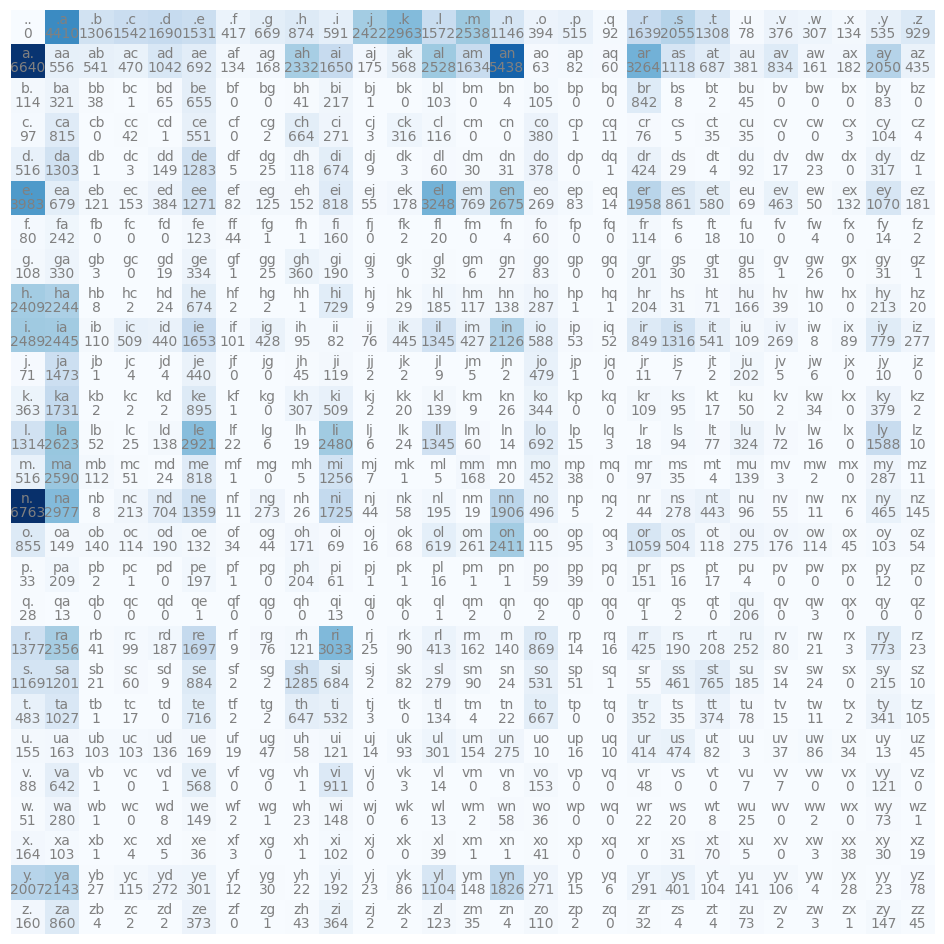

In [5]:
## Visualize Bigram Counts
plt.figure(figsize=(12, 12))
plt.imshow(N, cmap="Blues")

for i in range(vocab_size):
    for j in range(vocab_size):
        pair=itos[i]+itos[j]
        plt.text(j, i, pair, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")
        
plt.axis("off")
plt.show()

In [6]:
# Convert Counts to Probabilities
P=(N+1).float()
P /=P.sum(dim=1, keepdim=True)
print("Probability of a:", P[0].sum())

Probability of a: tensor(1.)


## Greedy Decoding

In [7]:
def generate_greedy(P, stoi, itos):
    ix=stoi['.']
    name=[]
    
    while True:
        probs=P[ix]
        ix=torch.argmax(probs).item()
        
        if ix==stoi["."]:
            break
        
        name.append(itos[ix])
    
    return ''.join(name)

In [17]:
# Test
for _ in range(5):
    print(generate_greedy(P, stoi, itos))

a
a
a
a
a


## Random Sampling

In [9]:
def generate_random(P, stoi, itos):
    ix=stoi["."]
    name=[]
    
    while True:
        probs=P[ix]
        ix=torch.multinomial(
            probs, num_samples=1
        ).item()
        
        if ix==stoi["."]:
            break
        
        name.append(itos[ix])

    return "".join(name)        

In [14]:
# Test
for _ in range(10):
    print(generate_random(P, stoi, itos))


an
eannthes
ha
amylain
anceillove
oeesa
wabeleenishr
ziyistasathamovi
don
aimeaiahalimel


## Top-K Sampling

In [18]:
K=5

def generate_top_k(P, stoi, itos, k=5):
    ix=stoi["."]
    name=[]
    
    while True:
        probs=P[ix]
        
        top_probs, top_indices=torch.topk(
            probs, k
        )
        top_probs=top_probs/top_probs.sum()
        
        choice=torch.multinomial(
            top_probs, num_samples=1
        ).item()
        
        ix=top_indices[choice].item()
        
        if ix==stoi["."]:
            break
        name.append(itos[ix])
        
        
    return "".join(name)
        

In [19]:
# Test
for _ in range(10):
    print(generate_top_k(P, stoi, itos, k=5))

anelelelya
kan
ma
senn
a
a
a
an
ja
kyn
